## Least Squares Method

In [8]:
import numpy as np
# Data points
X = np.array([1, 2, 3, 4, 5])
Y = np.array([1.2, 2.8, 3.6, 4.5, 5.1])
# Stack the design matrix with a column of ones (for the intercept)
A = np.vstack([X, np.ones(len(X))]).T
# Solve using least squares
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]
print(f"Slope: {m}, Intercept: {c}")

Slope: 0.9500000000000001, Intercept: 0.5900000000000001


## Line and Plot

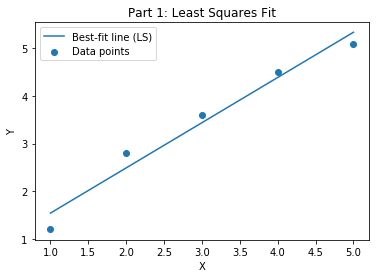

In [9]:
x_line = np.linspace(X.min(), X.max(), 200)
y_line = m * x_line + c

plt.figure()
plt.scatter(X, Y, label="Data points")
plt.plot(x_line, y_line, label="Best-fit line (LS)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 1: Least Squares Fit")
plt.legend()
plt.show()

## Randomize

In [10]:
rng = np.random.default_rng(0)
Y_rand = rng.permutation(Y)

A2 = np.vstack([X, np.ones(len(X))]).T
m2, c2 = np.linalg.lstsq(A2, Y_rand, rcond=None)[0]

print("\nPart 2")
print("Randomized Y =", Y_rand)
print("Slope =", m2)
print("Intercept =", c2)


Part 2
Randomized Y = [3.6 5.1 4.5 1.2 2.8]
Slope = -0.5500000000000002
Intercept = 5.090000000000001


## New Plot

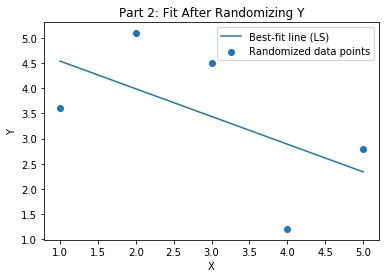

In [11]:
x_line2 = np.linspace(X.min(), X.max(), 200)
y_line2 = m2 * x_line2 + c2

plt.figure()
plt.scatter(X, Y_rand, label="Randomized data points")
plt.plot(x_line2, y_line2, label="Best-fit line (LS)")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Part 2: Fit After Randomizing Y")
plt.legend()
plt.show()


The fit is usually worse, as shuffling y breaks the x-y trend, so the line often looks less meaningful.

## Own Linear Equation

In [12]:
m_true = 2.5
c_true = 0.3

x3 = np.arange(0, 1.01, 0.01)  
noise = rng.normal(loc=0.0, scale=0.05, size=len(x3))  
y3 = m_true * x3 + c_true + noise

A3 = np.vstack([x3, np.ones(len(x3))]).T
m3, c3 = np.linalg.lstsq(A3, y3, rcond=None)[0]

print("\nPart 3")
print("True slope =", m_true, " True intercept =", c_true)
print("Fit  slope =", m3,     " Fit  intercept =", c3)


Part 3
True slope = 2.5  True intercept = 0.3
Fit  slope = 2.507919073700285  Fit  intercept = 0.2998668778890312


## Line and plot own equation

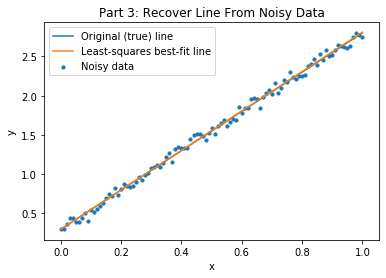

In [13]:
x_line3 = np.linspace(x3.min(), x3.max(), 400)
y_fit3 = m3 * x_line3 + c3
y_true3 = m_true * x_line3 + c_true

plt.figure()
plt.scatter(x3, y3, s=10, label="Noisy data")
plt.plot(x_line3, y_true3, label="Original (true) line")
plt.plot(x_line3, y_fit3, label="Least-squares best-fit line")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Part 3: Recover Line From Noisy Data")
plt.legend()
plt.show()